# Held-out check of gold-free NL→FOL faithfulness metrics: demo

This notebook demos **experiment `art_9sEYxfGs3C-z`** (iteration 2 of run `qY2a2IS-WLIs`). It checks, on held-out data and with every setting frozen in advance, whether *gold-free* metrics predict if a candidate first-order-logic (FOL) formula is **faithful** to its natural-language sentence.

**The full experiment:**
- Covered 700 held-out sentences (FOLIO / MALLS / ProverQA) × 9 translator systems, giving 6,300 candidate formalizations.
- Scored every candidate with the frozen iteration-1 metrics:
  - **LC_\*** – latent-class agreement across the 9 systems. Candidates are grouped into solver-checked equivalence classes, and a one-coin / Hui-Walter / Dawid-Skene latent-class model estimates P(faithful).
  - **A3 / A0 / Ccov** – a zero-LLM monotonicity signature, an alignment-only control and a coverage control.
  - **A1** – an LLM text probe.
  - **Baselines:** B1 cheap LLM judge (gemini-2.5-flash), B1plus frontier judge (gemini-2.5-pro), B2 parse rate, B3cos/B3nli round-trip similarity, B7 structural consistency, B8 sampling self-consistency.
- The primary labels are 609 items adjudicated by a 3-judge panel (`panel3`). Each item has a post-stratification weight.
- The pre-registered confirmation rule is **C1** AUROC_P ≥ .70, **C2** cross-fitted ΔAUROC over the frozen base `[B1, B2, B3nli, B3cos, B7]` with 95% lower bound > 0, and **C3** coverage ≥ 70%.

**What runs here.** `method.py` is a stage orchestrator. Its early stages (`frame` → `zero_llm` → `llm` → `local`) need Z3/solver workers, paid OpenRouter LLM calls and a GPU, and took hours. The notebook takes the metric scores those stages exported (`predict_<metric>` in `full_method_out.json`) for a **100-item curated subset of the 609 panel items**. It then re-runs the **`analysis` stage** (`src/analysis.py` + `src/stats.py`) on them with the original code:
- weighted AUROC with a stratified sentence bootstrap,
- per-error-type sensitivity,
- the cross-fitted stacking test (C2) and the C1–C3 verdict,
- the circularity check,
- system-level Kendall τ,
- AUROC by complexity tercile.

With 100 items instead of 609, the confidence intervals are wider than in the full run. The final cell sets the demo numbers beside the full-run numbers stored in the data file.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install (the original analysis code logs with loguru)
_pip('loguru==0.7.3')

# numpy, scipy, scikit-learn, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- original imports of method.py ---
from __future__ import annotations

import argparse
import os
import resource
import sys
from pathlib import Path

# --- original imports of src/stats.py and src/analysis.py ---
import json
import math
import time
from collections import Counter, defaultdict

import numpy as np
from loguru import logger

# --- notebook-only additions (logging to the cell output + plots) ---
logger.remove()
logger.add(sys.stdout, format="{time:HH:mm:ss} | {level} | {message}", level="INFO")
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-abf543-do-sentence-and-formula-generalize-the/main/round-2/experiment-3/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(len(data["examples"]), "examples |", data["metadata"]["selection"])
ex0 = data["examples"][0]
print(json.loads(ex0["input"]))
print("panel label:", ex0["output"], "| system:", ex0["metadata_system"], "| B1 =", ex0["predict_B1"],
      "| LC_onecoin =", ex0["predict_LC_onecoin"])

100 examples | 100 of the 609 panel3-labelled held-out items, stratified by corpus x panel label (seed 0)
{'sentence': 'If Dr. Yareli Hernandez is empathetic, then she is either respectful of boundaries or listens actively (but not both).', 'candidate_fol': '∀x ( (Empathetic(y) ) → (Respectful(y) ⊕ Listens(y) ) )'}
panel label: unfaithful | system: gpt-oss-120b | B1 = 0.5000 | LC_onecoin = 0.0000


## The orchestrator (`method.py`)

In the original repository `method.py` is run as `uv run method.py --stage {frame,adapter,preflight,mini,zero_llm,llm,local,analysis,rerank,transfer,export,all}`. The cell below copies its stage dispatch unchanged and replaces the stage calls with a description. Only the **`analysis`** stage is re-executed in this notebook, on the scores the earlier stages produced.

In [5]:
# Copied from method.py main(): the stage sequence for --stage all / mini
stages = ["frame", "adapter", "preflight", "zero_llm", "llm", "local", "analysis", "rerank", "transfer", "export"]
WHAT = {
    "frame": "join the held-out dataset rows (700 sentences x 9 systems) into one frame",
    "adapter": "canonicalise candidate FOL into the iter-1 parser dialect (D-adapter)",
    "preflight": "re-run the vendored iter-1 code on the screen set; LC_onecoin 833/833, A3 50/50 reproduce",
    "zero_llm": "LC_* latent-class metrics (solver pair checks), A3/A0/Ccov signatures, B2, B7 structural",
    "llm": "frozen OpenRouter metrics: B1, B1plus, A1, B3 round-trip ($2.70 total)",
    "local": "Qwen3-8B local-GPU substitutes (suffix L) for metrics hit by the key outage",
    "analysis": "AUROCs, bootstrap CIs, C1-C3 confirmation, circularity, system-level, complexity  <-- RUN HERE",
    "rerank": "screen re-rank under audited labels",
    "transfer": "A3 error typing on the unlabeled EU-AI-Act transfer set",
    "export": "write method_out.json (predict_<metric> per item)  -> source of mini_demo_data.json",
}
for st in stages:
    print(f"{st:10s} {WHAT[st]}")

frame      join the held-out dataset rows (700 sentences x 9 systems) into one frame
adapter    canonicalise candidate FOL into the iter-1 parser dialect (D-adapter)
preflight  re-run the vendored iter-1 code on the screen set; LC_onecoin 833/833, A3 50/50 reproduce
zero_llm   LC_* latent-class metrics (solver pair checks), A3/A0/Ccov signatures, B2, B7 structural
llm        frozen OpenRouter metrics: B1, B1plus, A1, B3 round-trip ($2.70 total)
local      Qwen3-8B local-GPU substitutes (suffix L) for metrics hit by the key outage
analysis   AUROCs, bootstrap CIs, C1-C3 confirmation, circularity, system-level, complexity  <-- RUN HERE
rerank     screen re-rank under audited labels
transfer   A3 error typing on the unlabeled EU-AI-Act transfer set
export     write method_out.json (predict_<metric> per item)  -> source of mini_demo_data.json


## Configuration

These are all the tunable parameters of the analysis stage.
- `NBOOT` is the number of stratified sentence-bootstrap resamples used for every confidence interval. The original is 1000.
- `OOF_K` and `OOF_NREP` set the cross-fitted logistic stacking: sentence-grouped k folds × n shuffles. The originals are 5 and 5.
- `MIN_CELL_N` is the smallest (sentence-bootstrap) cell size used in the complexity breakdown. The original is 40, which a 100-item demo cannot meet, so cells below it are flagged, as the original code does.

In [6]:
NBOOT = 1000        # bootstrap resamples per CI            (original: 1000)
OOF_K = 5                # sentence-grouped folds in stacking    (original: 5)
OOF_NREP = 5      # shuffles averaged in stacking         (original: 5)
COMPLEXITY_NBOOT = min(300, NBOOT)   # per-cell bootstrap in the complexity breakdown (original: 300)
MIN_CELL_N = 40          # cells smaller than this are flagged 'insufficient_n' (original: 40)
SEED = 0                 # bootstrap seed (original: 0)

## Statistics helpers (`src/stats.py`, verbatim)

- **`wauc`**: a weighted, tie-aware AUROC. Pairs are formed between positive and negative items, and each pair is weighted by the product of the two items' post-stratification weights. It equals `sklearn.roc_auc_score(sample_weight=w)`.
- **`soft_auc`**: the same AUROC computed with soft labels.
- **`kish`**: Kish's effective sample size of a weight vector.
- **`StratBoot`**: resamples *sentences* (not items) within the corpus × complexity-tercile strata. The draws are made once and shared by all metrics, so metric-vs-metric deltas are paired.
- **`oof_stack`**: cross-fitted logistic stacking, used for the C2 "adds signal over the baselines" test.
- **`kendall_pairwise`**: Kendall's τ-b between systems, used for the system-level analysis.

The only change is that `NBOOT` and the stacking defaults read the config cell.

In [7]:
# NBOOT = 1000   <- original module constant; now set in the config cell


def wauc(y, s, w=None) -> float:
    '''Weighted AUROC = sum_{i in pos, j in neg} w_i w_j (1[s_i>s_j] + 0.5 1[s_i=s_j]) / (W+ W-). Ties handled by
    grouping equal scores. Equals sklearn roc_auc_score(y, s, sample_weight=w).'''
    y = np.asarray(y, dtype=float)
    s = np.asarray(s, dtype=float)
    w = np.ones(len(y)) if w is None else np.asarray(w, dtype=float)
    wp, wn = w * y, w * (1 - y)
    Wp, Wn = wp.sum(), wn.sum()
    if Wp <= 0 or Wn <= 0:
        return float("nan")
    order = np.argsort(s, kind="mergesort")
    s_o, wp_o, wn_o = s[order], wp[order], wn[order]
    uniq, idx = np.unique(s_o, return_index=True)
    gp = np.add.reduceat(wp_o, idx)
    gn = np.add.reduceat(wn_o, idx)
    cum_n_below = np.concatenate([[0.0], np.cumsum(gn)[:-1]])
    num = (gp * cum_n_below).sum() + 0.5 * (gp * gn).sum()
    return float(num / (Wp * Wn))


def wauc_pairwise(y, s, w=None) -> float:
    '''O(n^2) hand implementation (T0b cross-check).'''
    y = np.asarray(y, dtype=int)
    s = np.asarray(s, dtype=float)
    w = np.ones(len(y)) if w is None else np.asarray(w, dtype=float)
    P, N = np.where(y == 1)[0], np.where(y == 0)[0]
    if len(P) == 0 or len(N) == 0:
        return float("nan")
    num = den = 0.0
    for i in P:
        d = s[i] - s[N]
        num += w[i] * (w[N] * ((d > 0) + 0.5 * (d == 0))).sum()
        den += w[i] * w[N].sum()
    return float(num / den)


def soft_auc(q, s, w=None) -> float:
    '''Expected AUROC with soft labels: item i is positive with weight q_i*w_i and negative with (1-q_i)*w_i;
    self-pairs (i as both positive and negative) are excluded.'''
    q = np.asarray(q, dtype=float)
    s = np.asarray(s, dtype=float)
    w = np.ones(len(q)) if w is None else np.asarray(w, dtype=float)
    yy = np.r_[np.ones(len(q)), np.zeros(len(q))]
    ss = np.r_[s, s]
    ww = np.r_[q * w, (1 - q) * w]
    Wp, Wn = (q * w).sum(), ((1 - q) * w).sum()
    a = wauc(yy, ss, ww)
    if math.isnan(a):
        return a
    num = a * Wp * Wn - 0.5 * (q * (1 - q) * w * w).sum()
    den = Wp * Wn - (q * (1 - q) * w * w).sum()
    return float(num / den) if den > 0 else float("nan")


def kish(w) -> float:
    w = np.asarray(w, dtype=float)
    return float(w.sum() ** 2 / (w ** 2).sum()) if len(w) else 0.0


class StratBoot:
    '''Pre-drawn bootstrap resamples of SENTENCES within sentence-level strata (paired across metrics).'''

    def __init__(self, sids, strata_of_sid: dict, n: int = None, seed: int = SEED):
        n = NBOOT if n is None else n   # notebook: default n = NBOOT from the config cell
        sids = np.asarray(sids)
        self.idx_by = defaultdict(list)
        for i, s in enumerate(sids):
            self.idx_by[s].append(i)
        self.idx_by = {k: np.asarray(v) for k, v in self.idx_by.items()}
        by_stratum = defaultdict(list)
        for s in sorted(self.idx_by):
            by_stratum[strata_of_sid.get(s, "NA")].append(s)
        rng = np.random.default_rng(seed)
        self.draws = []
        for _ in range(n):
            pick = []
            for st in sorted(by_stratum):
                L = by_stratum[st]
                pick.extend(L[j] for j in rng.choice(len(L), size=len(L), replace=True))
            self.draws.append(np.concatenate([self.idx_by[s] for s in pick]))
        self.by_stratum = {k: len(v) for k, v in by_stratum.items()}

    def __iter__(self):
        return iter(self.draws)


def ci(vals) -> list:
    v = np.array([x for x in vals if x is not None and not (isinstance(x, float) and math.isnan(x))])
    if len(v) == 0:
        return [None, None]
    return [float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))]


def boot_stat(boot: StratBoot, fn) -> list:
    return ci(fn(idx) for idx in boot)


def oof_stack(X: np.ndarray, y: np.ndarray, sids: np.ndarray, w: np.ndarray | None = None, k: int = OOF_K,
              n_rep: int = OOF_NREP, seed0: int = 100) -> np.ndarray:
    '''Sentence-grouped k-fold x n_rep shuffles; standardised features; LogisticRegression(C=1, lbfgs, max_iter 2000)
    fitted with sample weights; OOF probabilities averaged over shuffles.'''
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    y = np.asarray(y).astype(int)
    w = np.ones(len(y)) if w is None else np.asarray(w, dtype=float)
    uniq = np.unique(sids)
    out = np.zeros(len(y))
    for r in range(n_rep):
        rng = np.random.default_rng(seed0 + r)
        perm = rng.permutation(uniq)
        fold_of = {s: i % k for i, s in enumerate(perm)}
        f = np.array([fold_of[s] for s in sids])
        p = np.zeros(len(y))
        for j in range(k):
            tr, te = f != j, f == j
            if te.sum() == 0:
                continue
            if len(np.unique(y[tr])) < 2:
                p[te] = np.average(y[tr], weights=w[tr])
                continue
            sc = StandardScaler().fit(X[tr])
            m = LogisticRegression(C=1.0, solver="lbfgs", max_iter=2000).fit(sc.transform(X[tr]), y[tr],
                                                                            sample_weight=w[tr])
            p[te] = m.predict_proba(sc.transform(X[te]))[:, 1]
        out += p / n_rep
    return out


def kendall_pairwise(metric_s: dict, truth_s: dict) -> dict:
    from scipy.stats import kendalltau
    ks = sorted(set(metric_s) & set(truth_s))
    m = np.array([metric_s[k] for k in ks])
    t = np.array([truth_s[k] for k in ks])
    tau = kendalltau(m, t, variant="b").statistic if len(ks) >= 3 else float("nan")
    agree = tot = 0
    for i in range(len(ks)):
        for j in range(i + 1, len(ks)):
            if t[i] == t[j]:
                continue
            tot += 1
            agree += (m[i] - m[j]) * (t[i] - t[j]) > 0
    return {"tau_b": None if tau is None or (isinstance(tau, float) and math.isnan(tau)) else float(tau),
            "pairwise_acc": agree / tot if tot else None, "n_pairs": tot, "n_systems": len(ks)}

# T0b check from analysis.run(): the fast AUROC equals sklearn and the O(n^2) reference
from sklearn.metrics import roc_auc_score
_rng = np.random.default_rng(0)
yy, ss, ww = _rng.integers(0, 2, 300), _rng.integers(0, 10, 300) / 10, _rng.random(300)
print("wauc vs sklearn  |diff| =", abs(wauc(yy, ss, ww) - roc_auc_score(yy, ss, sample_weight=ww)))
print("wauc vs pairwise |diff| =", abs(wauc(yy, ss, ww) - wauc_pairwise(yy, ss, ww)))

wauc vs sklearn  |diff| = 1.1102230246251565e-16
wauc vs pairwise |diff| = 4.440892098500626e-16


## Frozen metric lists and pre-registered sets (`src/scores.py`, `src/common.py`, `src/analysis.py`)

- `BASE` is the frozen "best other baselines" feature set used by the C2 stacking test.
- `CANDIDATES` are the metrics being tested.
- `LOCAL_SUB` maps each frozen gemini metric to its local Qwen3-8B substitute. A substitute is used only if the frozen metric was not run (deviation D-LLM).
- `PANEL_ONLY` and `TWO_SYS` metrics were run on restricted item sets, so their coverage (C3) is computed over the rows they ran on.

In [8]:
# src/common.py
SYSTEMS = ["deepseek-v3.1", "gemini-2.5-flash", "gemma-3-27b", "gpt-4.1-mini", "gpt-oss-120b", "llama-3.1-8b",
           "mistral-small-3.2-24b", "phi-4", "qwen-2.5-7b"]
SAMPLE_SYSTEMS = ["gpt-4.1-mini", "llama-3.1-8b"]

# src/scores.py
LC_METRICS = ["LC_onecoin", "LC_onecoin_str", "LC_huiwalter", "LC_maj", "LC_ds_binary", "LC_granular"]
METRICS = LC_METRICS + ["LC_within", "A3", "A1", "A0", "Ccov", "B1", "B1plus", "B2", "B2_armB", "B3cos", "B3nli",
                        "B3c", "B7", "B7_arity_self", "B7_arity_story", "B7_joint", "B7_jacc", "B8",
                        # local-GPU substitutes (Qwen3-8B; same frozen prompts) -- see src/local_llm.py
                        "B1L", "B1plusL", "A1L", "B3cosL", "B3nliL", "B3cL"]

# src/analysis.py
BASE = ["B1", "B2", "B3nli", "B3cos", "B7"]  # FROZEN 'best other baselines' (plan 5.2)
CANDIDATES = ["LC_onecoin", "LC_huiwalter", "LC_maj", "LC_ds_binary", "LC_onecoin_str", "LC_granular", "A3", "A1", "A0",
              "Ccov", "B1plus", "B3c", "B7_jacc", "B8", "LC_within"]
CROSSOVER = ["LC_onecoin", "A3", "A1", "B1plus", "B3nli"]
PANEL_ONLY = {"B1plus", "B3cos", "B3nli", "B3c", "B1plusL", "B3cosL", "B3nliL", "B3cL", "A1"}
LOCAL_SUB = {"B1": "B1L", "B1plus": "B1plusL", "A1": "A1L", "B3cos": "B3cosL", "B3nli": "B3nliL", "B3c": "B3cL"}


def resolve(m: str, metrics: list[str]) -> str | None:
    '''Frozen metric if it was run, else its local-GPU substitute (declared in results/deviations.json).'''
    if m in metrics:
        return m
    s = LOCAL_SUB.get(m)
    return s if s in metrics else None
TWO_SYS = {"LC_within", "B8", "B7_jacc"}
TERC = {"bottom": 1, "middle": 2, "top": 3}
FAMILY = {"google": {"gemini-2.5-flash", "gemma-3-27b"}, "openai": {"gpt-4.1-mini", "gpt-oss-120b"}}


def nbin(n):
    return "0-1" if n <= 1 else ("2-3" if n <= 3 else "4+")

## Loading the data frame (adapted `Data` class)

In the original, `Data.__init__` loads the dataset frame (`load_frame()`) and builds the wide score table `W[item_id][metric] = (score, covered)` from the per-stage caches in `work/`. Here the same frame is rebuilt from the exported fields of `mini_demo_data.json`:
- `predict_<metric>` gives the score.
- `metadata_uncovered_metrics` gives the covered flag. An uncovered item keeps the pre-registered score of 0.5 and stays in every analysis.
- `metadata_*` gives the frame columns.

`_labels()` is the original. The demo holds only panel-labelled items, so every row has `y_panel`, a panel weight `w` and `q = y_panel`. Two soft-label fields that were not exported are set to `None`: `L3_design_weight` and `L3_stratum_p_faithful`. `L1_orig_status` is set equal to `L1_audited_status`.

In [9]:
def load_frame_from_demo(data):
    '''Notebook adapter: rebuild frame rows + the wide score table W from the exported predict_/metadata_ fields.'''
    rows, W = [], defaultdict(dict)
    for e in data["examples"]:
        inp = json.loads(e["input"])
        r = {k[len("metadata_"):]: v for k, v in e.items() if k.startswith("metadata_")}
        r.update(sentence=inp["sentence"], candidate_fol=inp["candidate_fol"], output=e["output"],
                 gold_source=None, L1_orig_status=r["L1_audited_status"], L3_design_weight=None,
                 L3_stratum_p_faithful=None, L3_dissent=None)
        rows.append(r)
        unc = set(e["metadata_uncovered_metrics"])
        for k, v in e.items():
            if k.startswith("predict_"):
                m = k[len("predict_"):]
                W[r["item_id"]][m] = (float(v), m not in unc)
    return rows, W


class Data:
    def __init__(self, data):
        rows, self.W = load_frame_from_demo(data)       # notebook: replaces load_frame() + build_long() + wide()
        self.rows = rows
        self.G = [r for r in rows if r["fold"] == "heldout_confirm"]
        self.C = []                                      # contamination fold not included in the demo subset
        self.eq_unfaithful = 0.0988                      # label_report L3 equivalent-but-unfaithful weighted rate
        self._labels()

    def _labels(self):
        for r in self.G:
            ls, out = r["label_source"], r["output"]
            r["y_panel"] = (1 if out == "faithful" else 0) if (ls == "panel3" and out in ("faithful", "unfaithful")) else None
            r["y_solver"] = {"faithful": 1, "unfaithful": 0}.get(out)
            st = r["L1_orig_status"] if (r["corpus"] == "proverqa" and r["gold_source"] == "original") else r[
                "L1_audited_status"]
            r["y_solver_pure"] = 1 if st in ("equiv_proved", "equiv_bounded") else (
                0 if st in ("non_equiv", "non_equiv_no_bijection") else None)
            r["L1_used_status"] = st
            if r["y_panel"] is not None:
                q = float(r["y_panel"])
            elif not r["parse_ok"]:
                q = 0.0
            elif out == "faithful":
                q = 1 - self.eq_unfaithful
            elif out == "unfaithful":
                q = r["L3_stratum_p_faithful"]
            else:
                q = None
            r["q"] = q
            r["w"] = r["L3_sampling_weight"] if r["y_panel"] is not None else None
            r["wd"] = r["L3_design_weight"] if r["y_panel"] is not None else None
            r["tn"] = TERC[r["complexity_tercile"]]
            r["nbin"] = nbin(r["n_conditions"] or 0)
            r["unanimous"] = (r["y_panel"] is not None) and not r.get("L3_dissent")

    def col(self, rows, m):
        '''score vector (uncovered/missing -> 0.5) and 'present' mask (metric was run on the item).'''
        s, pres, cov = [], [], []
        for r in rows:
            v = self.W.get(r["item_id"], {}).get(m)
            s.append(0.5 if v is None else v[0])
            pres.append(v is not None)
            cov.append(bool(v and v[1]))
        return np.array(s, dtype=float), np.array(pres), np.array(cov)


def strata(rows):
    return {r["sentence_id"]: f"{r['corpus']}|{r['complexity_tercile']}" for r in rows}


D = Data(data)
G = D.G
P = [r for r in G if r["y_panel"] is not None]
print(f"G={len(G)} items, panel P={len(P)} over {len({r['sentence_id'] for r in P})} sentences; "
      f"labels={dict(Counter(r['y_panel'] for r in P))}; Kish n_eff={kish([r['w'] for r in P]):.1f}")

G=100 items, panel P=100 over 93 sentences; labels={0: 50, 1: 50}; Kish n_eff=57.2


## Item-level AUROC per metric (`auc_block`, from `analysis.run` §5.1)

For each metric the notebook reports:
- the weighted AUROC against the panel labels (**P**), with a stratified sentence-bootstrap 95% CI;
- the unweighted AUROC (**S**). In the full run S uses solver labels on all 5,847 labelled rows. On this panel-only subset it is the unweighted panel AUROC;
- coverage over the rows the metric was run on.

`RANDOM` is the original placebo metric, a uniform score seeded by the item id, so its AUROC should sit near 0.5.

In [10]:
import hashlib
def sha1(s: str) -> str:
    return hashlib.sha1(s.encode()).hexdigest()


def auc_block(D: Data, rows, m, ykey="y_panel", wkey="w", boot: StratBoot | None = None) -> dict:
    s, pres, cov = D.col(rows, m)
    y = np.array([r[ykey] for r in rows], dtype=float)
    w = np.array([r[wkey] if wkey else 1.0 for r in rows], dtype=float) if wkey else np.ones(len(rows))
    msk = pres
    if msk.sum() < 5 or len(np.unique(y[msk])) < 2:
        return {"auroc": None, "ci": [None, None], "n": int(msk.sum())}
    a = wauc(y[msk], s[msk], w[msk])
    lo_hi = [None, None]
    if boot is not None:
        vals = []
        for idx in boot:
            ii = idx[msk[idx]]
            if len(ii) > 5 and len(np.unique(y[ii])) == 2:
                vals.append(wauc(y[ii], s[ii], w[ii]))
        lo_hi = ci(vals)
    return {"auroc": a, "ci": lo_hi, "n": int(msk.sum()), "n_pos": int(y[msk].sum()),
            "kish_n_eff": kish(w[msk]) if wkey else None}


def _f(x):
    return "NA" if x is None or (isinstance(x, float) and math.isnan(x)) else f"{x:.3f}"


def _ci(c):
    return f"[{_f(c[0])},{_f(c[1])}]" if c else ""


t0 = time.time()
S = [r for r in G if r["y_solver"] is not None]
bP = StratBoot([r["sentence_id"] for r in P], strata(P))
bS = StratBoot([r["sentence_id"] for r in S], strata(S))
# placebo random metric
for r in G:
    D.W[r["item_id"]]["RANDOM"] = (float(np.random.default_rng(int(sha1(r["item_id"])[:8], 16)).random()), True)
# a metric is 'available' only if at least one held-out item was actually scored (covered)
metrics = [m for m in METRICS if any(D.W.get(r["item_id"], {}).get(m, (0, False))[1] for r in G)] + ["RANDOM"]
table = {}
for m in metrics:
    t = {}
    t["P"] = auc_block(D, P, m, "y_panel", "w", bP)
    t["S"] = auc_block(D, S, m, "y_solver", None, bS)
    _, presG, covG = D.col(G, m)
    t["coverage_all_G"] = float(covG.mean())
    t["coverage_run_rows"] = float(covG[presG].mean()) if presG.sum() else None
    t["n_run_rows"] = int(presG.sum())
    table[m] = t
    logger.info(f"{m}: P={_f(t['P']['auroc'])} {_ci(t['P']['ci'])} S={_f(t['S']['auroc'])} "
                f"cov={t['coverage_run_rows']:.3f} n={t['P']['n']}")
print(f"base features used: {[resolve(b, metrics) for b in BASE if resolve(b, metrics)]}; {time.time() - t0:.1f}s")

19:23:27 | INFO | LC_onecoin: P=0.722 [0.586,0.833] S=0.696 cov=0.990 n=100


19:23:27 | INFO | LC_onecoin_str: P=0.723 [0.586,0.834] S=0.699 cov=0.990 n=100


19:23:27 | INFO | LC_huiwalter: P=0.714 [0.579,0.825] S=0.693 cov=0.990 n=100


19:23:28 | INFO | LC_maj: P=0.710 [0.562,0.843] S=0.711 cov=0.990 n=100


19:23:28 | INFO | LC_ds_binary: P=0.724 [0.577,0.852] S=0.719 cov=0.990 n=100


...

19:23:29 | INFO | B3cosL: P=0.695 [0.568,0.799] S=0.638 cov=1.000 n=100


19:23:29 | INFO | B3nliL: P=0.695 [0.556,0.822] S=0.714 cov=1.000 n=100


19:23:29 | INFO | B3cL: P=0.600 [0.514,0.680] S=0.630 cov=1.000 n=100


19:23:29 | INFO | RANDOM: P=0.558 [0.418,0.712] S=0.580 cov=1.000 n=100


base features used: ['B1', 'B2', 'B3nli', 'B3cos', 'B7']; 1.8s


## Sensitivity per real error type (`per_error_type`, verbatim)

The panel tagged each unfaithful item with its primary error type, for example `added_condition`, `quantifier_forall_exists` or `dropped_condition`. For each type the code computes the AUROC of *panel-faithful items vs. items with that error*. The original reports only types with ≥ 10 unfaithful items. On 100 items, just the most common types reach that threshold.

In [11]:
def per_error_type(D: Data, P, metrics) -> dict:
    '''Sensitivity per REAL error type: weighted AUROC of panel-faithful items vs panel-unfaithful items whose
    L3 primary error is t (n>=10 unfaithful items).'''
    types = Counter(r["L3_primary_error"] for r in P if r["y_panel"] == 0)
    out = {"type_counts_unweighted": dict(types)}
    for t, n in types.items():
        if n < 10:
            continue
        rows = [r for r in P if r["y_panel"] == 1 or r["L3_primary_error"] == t]
        out[t] = {}
        for m in metrics:
            s, pres, _ = D.col(rows, m)
            y = np.array([r["y_panel"] for r in rows], dtype=float)
            w = np.array([r["w"] for r in rows])
            if pres.sum() > 10 and len(np.unique(y[pres])) == 2:
                out[t][m] = {"auroc": wauc(y[pres], s[pres], w[pres]), "n_err": int(((y == 0) & pres).sum())}
    return out


pet = per_error_type(D, P, metrics)
print("unfaithful error types:", pet["type_counts_unweighted"])
show = ["LC_onecoin", "A3", "A1", "B1", "B1plus", "B3nli", "B7"]
for t in [k for k in pet if k != "type_counts_unweighted"]:
    print(f"{t:28s}", "  ".join(f"{m}={_f(pet[t].get(m, {}).get('auroc'))}" for m in show))

unfaithful error types: {'quantifier_forall_exists': 12, 'implication_direction_or_only': 5, 'added_condition': 15, 'quantifier_scope': 3, 'negation_polarity': 5, 'wrong_constant': 2, 'dropped_condition': 3, 'connective_and_or': 1, 'conflation': 2, 'argument_swap': 1, 'wrong_split': 1}
quantifier_forall_exists     LC_onecoin=0.885  A3=0.518  A1=0.465  B1=0.887  B1plus=0.931  B3nli=0.766  B7=0.577
added_condition              LC_onecoin=0.644  A3=0.787  A1=0.629  B1=0.684  B1plus=0.788  B3nli=0.632  B7=0.541


## Does a metric add signal over the baselines? Cross-fitted stacking, C2 (`stacking`, verbatim)

A logistic model is fitted on the frozen base `[B1, B2, B3nli, B3cos, B7]`. It is then refitted with one candidate metric added. Both models are cross-fitted: sentence-grouped out-of-fold predictions, averaged over shuffles. **C2** passes when the 95% bootstrap lower bound of ΔAUROC(with − without) is > 0.

The function also computes these, all from the original code:
- composite models (base+LC+A3, base+all);
- a base *without* the round-trip features;
- a placebo random feature, whose Δ should be ≈ 0;
- a second table with the frontier judge B1plus inside the base.

The 2-system B8 subset needs more than 30 items. It is skipped automatically here because the demo has only 21 items from the two sampled systems.

In [12]:
def _stack_eval(D, P, feats, bP, y, w, sids, placebo=None):
    X = np.column_stack([D.col(P, f)[0] for f in feats] + ([placebo] if placebo is not None else []))
    return oof_stack(X, y, sids, w)


def stacking(D: Data, P, bP: StratBoot, metrics) -> dict:
    y = np.array([r["y_panel"] for r in P])
    w = np.array([r["w"] for r in P])
    sids = np.array([r["sentence_id"] for r in P])
    base = [resolve(b, metrics) for b in BASE if resolve(b, metrics)]
    oof = {}
    oof["base"] = _stack_eval(D, P, base, bP, y, w, sids)

    def delta(tag_with, tag_wo):
        a1, a0 = oof[tag_with], oof[tag_wo]
        d = wauc(y, a1, w) - wauc(y, a0, w)
        vals = [wauc(y[i], a1[i], w[i]) - wauc(y[i], a0[i], w[i]) for i in bP]
        c = ci(vals)
        return {"auc_with": wauc(y, a1, w), "auc_without": wauc(y, a0, w), "delta": d, "ci": c,
                "lb_gt_0": bool(c[0] is not None and c[0] > 0)}
    res = {"base_features": base, "n": len(P), "auc_base": wauc(y, oof["base"], w), "per_metric": {}}
    for m in [x for x in metrics if x not in base and x not in TWO_SYS and x != "RANDOM"] + ["RANDOM"]:
        oof[m] = _stack_eval(D, P, base + [m], bP, y, w, sids)
        res["per_metric"][m] = delta(m, "base")
    # composite models
    a1 = resolve("A1", metrics) or "A1"
    combos = {"base+A3_over_base+A0": (["A0", "A3"], ["A0"]), "base+LC+A3": (["LC_onecoin", "A3"], []),
              f"base+LC+A3+{a1}": (["LC_onecoin", "A3", a1], []),
              "base+all": ([m for m in CANDIDATES + ["A1L", "B1plusL", "B3cL"] if m in metrics and m not in TWO_SYS
                             and m != "LC_granular" and m not in base], [])}
    res["combos"] = {}
    for name, (add, sub) in combos.items():
        if not all(a in metrics for a in add):
            continue
        tw, two = name + ":with", name + ":without"
        oof[tw] = _stack_eval(D, P, base + add, bP, y, w, sids)
        oof[two] = _stack_eval(D, P, base + sub, bP, y, w, sids) if sub else oof["base"]
        res["combos"][name] = delta(tw, two)
    # sensitivity: base WITHOUT the round-trip features (B3nli/B3cos or their substitutes) -> [judge, B2, B7]
    base_nb3 = [b for b in base if not b.startswith("B3")]
    if base_nb3 != base:
        oof["base_nb3"] = _stack_eval(D, P, base_nb3, bP, y, w, sids)
        res["base_without_roundtrip"] = {"base": base_nb3, "auc_base": wauc(y, oof["base_nb3"], w), "per_metric": {}}
        for m in ["LC_onecoin", "LC_maj", "LC_ds_binary", "LC_huiwalter", "A3", "A0", "Ccov", a1, "B3nliL", "B3nli"]:
            if m in metrics:
                oof[f"nb3:{m}"] = _stack_eval(D, P, base_nb3 + [m], bP, y, w, sids)
                res["base_without_roundtrip"]["per_metric"][m] = delta(f"nb3:{m}", "base_nb3")
    # placebo random-uniform feature
    rnd = np.random.default_rng(7).random(len(P))
    oof["placebo"] = _stack_eval(D, P, base, bP, y, w, sids, placebo=rnd)
    res["placebo_random_feature"] = delta("placebo", "base")
    # second table: B1plus added to the base
    b1p = resolve("B1plus", metrics)
    if b1p:
        base2 = base + [b1p]
        oof["base2"] = _stack_eval(D, P, base2, bP, y, w, sids)
        res["with_B1plus_in_base"] = {"auc_base": wauc(y, oof["base2"], w), "per_metric": {}, "B1plus_used": b1p}
        for m in ["LC_onecoin", "A3", a1, "A0", "LC_maj", "LC_huiwalter"]:
            if m in metrics:
                oof[f"b2:{m}"] = _stack_eval(D, P, base2 + [m], bP, y, w, sids)
                res["with_B1plus_in_base"]["per_metric"][m] = delta(f"b2:{m}", "base2")
    # B8 / LC_within table on the 2-system panel subset (B8 in base)
    sub = [i for i, r in enumerate(P) if r["system"] in SAMPLE_SYSTEMS]
    if len(sub) > 30 and "B8" in metrics:
        Ps = [P[i] for i in sub]
        ys, ws, ss = y[sub], w[sub], sids[sub]
        bS2 = StratBoot(ss, strata(Ps))
        b8base = base + ["B8"]
        o0 = _stack_eval(D, Ps, b8base, bS2, ys, ws, ss)
        r2 = {"n": len(Ps), "base": b8base, "auc_base": wauc(ys, o0, ws), "per_metric": {}}
        for m in ["LC_onecoin", "LC_within", "A3", a1, "B7_jacc"]:
            if m in metrics:
                o1 = _stack_eval(D, Ps, b8base + [m], bS2, ys, ws, ss)
                vals = [wauc(ys[i], o1[i], ws[i]) - wauc(ys[i], o0[i], ws[i]) for i in bS2]
                r2["per_metric"][m] = {"delta": wauc(ys, o1, ws) - wauc(ys, o0, ws), "ci": ci(vals)}
        # B8 itself over the 9-system base on this subset
        o_b = _stack_eval(D, Ps, base, bS2, ys, ws, ss)
        vals = [wauc(ys[i], o0[i], ws[i]) - wauc(ys[i], o_b[i], ws[i]) for i in bS2]
        r2["B8_over_base"] = {"delta": wauc(ys, o0, ws) - wauc(ys, o_b, ws), "ci": ci(vals)}
        res["two_system_subset"] = r2
    return res


t0 = time.time()
stack = stacking(D, P, bP, metrics)
print(f"stacking done in {time.time() - t0:.1f}s; base AUROC (cross-fitted) = {stack['auc_base']:.3f}")
for m in ["LC_onecoin", "LC_maj", "A3", "A1", "B1plus", "RANDOM"]:
    st = stack["per_metric"].get(m)
    if st:
        print(f"  +{m:12s} delta={st['delta']:+.3f} CI={_ci(st['ci'])} lb>0={st['lb_gt_0']}")
for name, st in stack["combos"].items():
    print(f"  {name:28s} delta={st['delta']:+.3f} CI={_ci(st['ci'])}")
print("  placebo random feature: delta =", _f(stack["placebo_random_feature"]["delta"]))

stacking done in 6.1s; base AUROC (cross-fitted) = 0.711
  +LC_onecoin   delta=-0.035 CI=[-0.074,-0.007] lb>0=False
  +LC_maj       delta=+0.011 CI=[-0.029,0.048] lb>0=False
  +A3           delta=+0.060 CI=[-0.042,0.180] lb>0=False
  +A1           delta=-0.010 CI=[-0.040,0.016] lb>0=False
  +B1plus       delta=+0.006 CI=[-0.028,0.042] lb>0=False
  +RANDOM       delta=-0.005 CI=[-0.030,0.023] lb>0=False
  base+A3_over_base+A0         delta=+0.028 CI=[-0.044,0.117]
  base+LC+A3                   delta=+0.023 CI=[-0.076,0.135]
  base+LC+A3+A1                delta=+0.037 CI=[-0.079,0.165]
  base+all                     delta=+0.069 CI=[-0.036,0.168]
  placebo random feature: delta = 0.062


## Pre-registered verdict C1 ∧ C2 ∧ C3 (`confirm`, verbatim)

- **C1:** AUROC_P ≥ .70.
- **C2:** the stacking lower bound is > 0.
- **C3:** coverage is ≥ 70%.

A metric is **CONFIRMED** only if all three hold. `LC_granular` was added post hoc and can never be confirmed.

In [13]:
def confirm(table, stack) -> dict:
    out = {}
    for m, t in table.items():
        a = t["P"]["auroc"]
        c1 = a is not None and a >= 0.70
        st = stack["per_metric"].get(m) or (stack.get("two_system_subset", {}).get("per_metric", {}).get(m))
        if m == "B8":  # B8 is the 2-system base member; its C2 is B8 over the 9-system base on that subset
            st = stack.get("two_system_subset", {}).get("B8_over_base")
        c2 = bool(st and st.get("ci") and st["ci"][0] is not None and st["ci"][0] > 0)
        cov = t["coverage_all_G"] if m not in PANEL_ONLY | TWO_SYS else t["coverage_run_rows"]
        c3 = cov is not None and cov >= 0.70
        aS = t["S"]["auroc"]
        out[m] = {"C1": bool(c1), "C2": c2, "C3": bool(c3), "CONFIRMED": bool(c1 and c2 and c3),
                  "C1_solver": bool(aS is not None and aS >= 0.70), "coverage_used_for_C3": cov,
                  "note": ("post-hoc; never a CONFIRM claim" if m == "LC_granular" else
                           "C2 on the 2-system subset" if m in TWO_SYS else "")}
        if m == "LC_granular":
            out[m]["CONFIRMED"] = False
    return out


confirmation = confirm(table, stack)
print("CONFIRMED metrics on the demo subset:", [m for m, c in confirmation.items() if c["CONFIRMED"]] or "none")

CONFIRMED metrics on the demo subset: ['B1L']


## Circularity: is LC just re-measuring the solver? (`circularity`, parts a + b)

LC builds its classes from *solver* equivalence checks, and some labels also come from the solver. The concern is that LC merely echoes that checker.
- **(a)** Compares each metric's AUROC under the panel labels with its AUROC under solver-only labels, on the same items.
- **(b)** Is the pre-registered test. It computes LC's AUROC *only inside the panel items that the solver found NOT equivalent to the gold formula*. There the solver alone carries no signal.

The pre-registered reading is *"not a checker artefact"* iff the lower bound of (b)'s CI is > 0.5 and the point estimate is ≥ 0.60. Part (c) needs the LC class-structure cache (`work/lc_struct.jsonl`), which is not in the exported data, so it is omitted.

In [14]:
def circularity(D: Data, P, bP) -> dict:
    res = {}
    comps = ["LC_onecoin", "LC_maj", "LC_huiwalter", "LC_onecoin_str", "LC_ds_binary", "LC_granular", "A3", "A1", "A0",
             "B1", "B1plus", "B3nli", "B3cos", "B3c", "B1L", "B1plusL", "A1L", "B3nliL", "B3cosL", "B3cL", "B7", "Ccov"]
    # (a) same 609 items: panel vs solver-pure labels
    Pa = [r for r in P if r["y_solver_pure"] is not None]
    y1 = np.array([r["y_panel"] for r in Pa], dtype=float)
    y2 = np.array([r["y_solver_pure"] for r in Pa], dtype=float)
    w = np.array([r["w"] for r in Pa])
    ba = StratBoot([r["sentence_id"] for r in Pa], strata(Pa))
    res["a_panel_vs_solver_same_items"] = {"n": len(Pa), "label_agreement_weighted":
                                           float(np.average(y1 == y2, weights=w))}
    for m in comps:
        s, pres, _ = D.col(Pa, m)
        if pres.sum() < 10:
            continue
        ap, as_ = wauc(y1[pres], s[pres], w[pres]), wauc(y2[pres], s[pres], w[pres])
        vals = []
        for idx in ba:
            ii = idx[pres[idx]]
            vals.append(wauc(y1[ii], s[ii], w[ii]) - wauc(y2[ii], s[ii], w[ii]))
        res["a_panel_vs_solver_same_items"][m] = {"auroc_panel": ap, "auroc_solver_pure": as_, "diff_panel_minus_solver":
                                                  ap - as_, "diff_ci": ci(vals)}
    # (b) inside solver-NON-equivalent panel items; (d) no-bijection only
    for tag, sts in (("b_nonequiv", ("non_equiv", "non_equiv_no_bijection")), ("d_no_bijection", ("non_equiv_no_bijection",))):
        Pb = [r for r in P if r["L1_audited_status"] in sts]
        yb = np.array([r["y_panel"] for r in Pb], dtype=float)
        wb = np.array([r["w"] for r in Pb])
        bb = StratBoot([r["sentence_id"] for r in Pb], strata(Pb))
        d = {"n": len(Pb), "faithful_share_weighted": float(np.average(yb, weights=wb)) if len(Pb) else None,
             "kish_n_eff": kish(wb)}
        for m in comps:
            s, pres, _ = D.col(Pb, m)
            if pres.sum() < 10 or len(np.unique(yb[pres])) < 2:
                continue
            a = wauc(yb[pres], s[pres], wb[pres])
            vals = []
            for idx in bb:
                ii = idx[pres[idx]]
                if len(np.unique(yb[ii])) == 2:
                    vals.append(wauc(yb[ii], s[ii], wb[ii]))
            c = ci(vals)
            reading = None
            if m == "LC_onecoin" or m.startswith("LC"):
                reading = ("not a checker artefact" if (c[0] is not None and c[0] > 0.5 and a >= 0.60) else
                           "partial" if (c[0] is not None and c[0] > 0.5) else "artefact")
            d[m] = {"auroc": a, "ci": c, "n": int(pres.sum()), "preregistered_reading": reading}
        res[tag] = d
    # (c) LC class position -- needs work/lc_struct.jsonl (not exported); omitted in the notebook
    res["reading_rule"] = ("'not a checker artefact' iff (b) AUROC 95% LB > 0.5 AND point >= 0.60; 'partial' iff LB > "
                           "0.5 but point < 0.60; 'artefact' iff CI includes 0.5")
    return res


circ = circularity(D, P, bP)
cb = circ["b_nonequiv"]
print(f"(b) solver-NON-equivalent panel items: n={cb['n']}, weighted faithful share={cb['faithful_share_weighted']:.2f}")
for m in ["LC_onecoin", "LC_maj", "A3", "B1"]:
    if m in cb:
        print(f"  {m:11s} AUROC={cb[m]['auroc']:.3f} CI={_ci(cb[m]['ci'])}  reading={cb[m]['preregistered_reading']}")

(b) solver-NON-equivalent panel items: n=90, weighted faithful share=0.39
  LC_onecoin  AUROC=0.577 CI=[0.445,0.721]  reading=artefact
  LC_maj      AUROC=0.628 CI=[0.516,0.747]  reading=not a checker artefact
  A3          AUROC=0.642 CI=[0.511,0.767]  reading=None
  B1          AUROC=0.667 CI=[0.542,0.784]  reading=None


## System-level agreement (`system_level`, verbatim)

This asks whether a metric ranks the 9 translator *systems* in the same order as their true faithfulness rate. It is measured with Kendall τ-b and pairwise accuracy. The original code notes that with n = 9 systems the analysis is underpowered by design and is not a gate. On 100 items, each system has only 6–14 items, so the demo ranking is noisy.

In [15]:
def system_level(D: Data, G, P, metrics, limit) -> dict:
    # truth: mean q over the system's items; unparseable = 0; unknown = corpus x tercile mean q among known
    cell = defaultdict(list)
    for r in G:
        if r["q"] is not None:
            cell[(r["corpus"], r["complexity_tercile"])].append(r["q"])
    cmean = {k: float(np.mean(v)) for k, v in cell.items()}
    qfill = np.array([r["q"] if r["q"] is not None else cmean[(r["corpus"], r["complexity_tercile"])] for r in G])
    n_unknown = sum(r["q"] is None for r in G)
    sysv = np.array([r["system"] for r in G])
    sids = np.array([r["sentence_id"] for r in G])
    boot = StratBoot(sids, strata(G), n=NBOOT if not limit else 200)
    wP = np.array([r["w"] for r in P])
    yP = np.array([r["y_panel"] for r in P], dtype=float)
    sysP = np.array([r["system"] for r in P])
    bootP = StratBoot([r["sentence_id"] for r in P], strata(P), n=NBOOT if not limit else 200)

    def per_sys(vals, sv, w=None, idx=None):
        idx = np.arange(len(vals)) if idx is None else idx
        out = {}
        for s in SYSTEMS:
            ii = idx[sv[idx] == s]
            if len(ii):
                out[s] = float(np.average(vals[ii], weights=None if w is None else w[ii]))
        return out
    truth = per_sys(qfill, sysv)
    truthP = per_sys(yP, sysP, wP)
    res = {"truth_all_items": truth, "truth_panel": truthP, "n_unknown_imputed": n_unknown,
           "note": "n=9 systems: Kendall tau null SD ~0.27; underpowered by design, NOT a gate", "metrics": {}}
    for m in metrics:
        sG, presG, _ = D.col(G, m)
        r = {}
        if presG.mean() > 0.99:
            ms = per_sys(sG, sysv)
            r["all_items"] = kendall_pairwise(ms, truth)
            r["all_items"]["metric_by_system"] = ms
            taus, accs = [], []
            for idx in boot:
                kp = kendall_pairwise(per_sys(sG, sysv, idx=idx), per_sys(qfill, sysv, idx=idx))
                taus.append(kp["tau_b"])
                accs.append(kp["pairwise_acc"])
            r["all_items"]["tau_ci"], r["all_items"]["acc_ci"] = ci(taus), ci(accs)
        sP, presP, _ = D.col(P, m)
        if presP.sum() > 0.9 * len(P):
            ms = per_sys(sP, sysP, wP)
            r["panel_items"] = kendall_pairwise(ms, truthP)
            r["panel_items"]["metric_by_system"] = ms
            taus = []
            for idx in bootP:
                taus.append(kendall_pairwise(per_sys(sP, sysP, wP, idx), per_sys(yP, sysP, wP, idx))["tau_b"])
            r["panel_items"]["tau_ci"] = ci(taus)
        res["metrics"][m] = r
    return res


t0 = time.time()
sys_lvl = system_level(D, G, P, ["LC_onecoin", "A3", "B1", "B1plus", "B3nli", "B7", "RANDOM"], None)
print(f"system level done in {time.time() - t0:.1f}s")
for m, r in sys_lvl["metrics"].items():
    pi = r.get("panel_items", {})
    print(f"  {m:11s} tau_b={_f(pi.get('tau_b'))} CI={_ci(pi.get('tau_ci'))} pairwise_acc={_f(pi.get('pairwise_acc'))}")

system level done in 5.0s
  LC_onecoin  tau_b=0.722 CI=[-0.111,0.778] pairwise_acc=0.861
  A3          tau_b=0.167 CI=[-0.056,0.722] pairwise_acc=0.583
  B1          tau_b=0.389 CI=[0.056,0.722] pairwise_acc=0.694
  B1plus      tau_b=0.444 CI=[-0.111,0.722] pairwise_acc=0.722
  B3nli       tau_b=0.556 CI=[0.054,0.833] pairwise_acc=0.778
  B7          tau_b=0.400 CI=[-0.236,0.691] pairwise_acc=0.444
  RANDOM      tau_b=0.000 CI=[-0.389,0.423] pairwise_acc=0.500


## Reliability vs. sentence complexity (`complexity`, per-cell part)

This splits AUROC_P by complexity tercile (`tn` = 1/2/3, from length, quantifiers, nesting and conditions) and by number of conditions (`nbin`). Long, heavily conditioned sentences are the case the user cares about most. The code is the original per-cell loop, restricted to the panel population P. Cells with fewer than `MIN_CELL_N` items, or fewer than 10 of either class, are flagged `insufficient_n`, as in the original. The bootstrap crossover and interaction tests of the original are omitted; the full run found no crossover.

In [16]:
def complexity(D: Data, P, metrics, limit) -> dict:
    res = {"per_cell": {}}
    pops = {"P": (P, "y_panel", "w")}
    for pname, (rows, yk, wk) in pops.items():
        for dim in ("tn", "nbin"):
            for val in sorted({r[dim] for r in rows}, key=str):
                cell = [r for r in rows if r[dim] == val]
                y = np.array([r[yk] for r in cell])
                n_pos, n_neg = int((y == 1).sum()), int((y == 0).sum())
                key = f"{pname}|{dim}={val}"
                ent = {"n": len(cell), "n_pos": n_pos, "n_neg": n_neg}
                if len(cell) < MIN_CELL_N or n_pos < 10 or n_neg < 10:
                    ent["insufficient_n"] = True
                bc = StratBoot([r["sentence_id"] for r in cell], strata(cell), n=COMPLEXITY_NBOOT)
                for m in metrics:
                    b = auc_block(D, cell, m, yk, wk, bc if not limit else None)
                    ent[m] = {"auroc": b["auroc"], "ci": b["ci"]}
                res["per_cell"][key] = ent
    return res


t0 = time.time()
cx_metrics = ["LC_onecoin", "A3", "A1", "B1", "B1plus", "B3nli"]
cx = complexity(D, P, cx_metrics, None)
print(f"complexity done in {time.time() - t0:.1f}s")
for key, ent in cx["per_cell"].items():
    flag = " (insufficient_n)" if ent.get("insufficient_n") else ""
    print(f"{key:10s} n={ent['n']:3d} pos={ent['n_pos']:2d}{flag:18s}",
          " ".join(f"{m}={_f(ent[m]['auroc'])}" for m in cx_metrics))

complexity done in 0.3s
P|tn=1     n= 22 pos=13 (insufficient_n)  LC_onecoin=0.642 A3=0.694 A1=0.737 B1=0.647 B1plus=0.787 B3nli=0.664
P|tn=2     n= 20 pos=11 (insufficient_n)  LC_onecoin=0.833 A3=0.861 A1=0.680 B1=0.743 B1plus=0.854 B3nli=0.898
P|tn=3     n= 58 pos=26                   LC_onecoin=0.673 A3=0.556 A1=0.443 B1=0.750 B1plus=0.778 B3nli=0.516
P|nbin=0-1 n= 35 pos=22 (insufficient_n)  LC_onecoin=0.834 A3=0.531 A1=0.502 B1=0.690 B1plus=0.862 B3nli=0.787
P|nbin=2-3 n= 41 pos=19                   LC_onecoin=0.536 A3=0.818 A1=0.720 B1=0.707 B1plus=0.741 B3nli=0.568
P|nbin=4+  n= 24 pos= 9 (insufficient_n)  LC_onecoin=0.772 A3=0.731 A1=0.661 B1=0.801 B1plus=0.890 B3nli=0.727


## Results: demo subset vs. full run

The table sets each key metric's weighted panel AUROC (with CI) and C2 ΔAUROC over the frozen base on the 100-item demo beside the full-run numbers on all 609 panel items (`metadata.full_run_confirmation_table`). The plots show:
1. AUROC_P per metric, demo against full run;
2. C2 ΔAUROC with CIs (a metric adds signal only if its CI lies entirely right of 0);
3. AUROC by complexity tercile.

metric       | demo AUROC_P [95% CI]      | demo C2 delta [CI]       | full AUROC_P [CI]        | full C2 delta | full CONFIRMED
-----------------------------------------------------------------------------------------------------------------------------
LC_onecoin   | 0.722 [0.586,0.833]       | -0.035 [-0.074,-0.007]   | 0.756 [0.701,0.808]      | +0.019        | False
LC_maj       | 0.710 [0.562,0.843]       | +0.011 [-0.029,0.048]    | 0.765 [0.710,0.816]      | +0.028        | False
LC_ds_binary | 0.724 [0.577,0.852]       | +0.039 [-0.027,0.104]    | 0.787 [0.733,0.836]      | +0.022        | False
LC_huiwalter | 0.714 [0.579,0.825]       | -0.035 [-0.075,-0.008]   | 0.755 [0.700,0.809]      | +0.019        | False
A3           | 0.702 [0.579,0.820]       | +0.060 [-0.042,0.180]    | 0.642 [0.589,0.695]      | +0.016        | False
A0           | 0.690 [0.561,0.803]       | +0.017 [-0.048,0.084]    | 0.656 [0.604,0.705]      | +0.015        | False
Ccov         | 0.680 [0.558,0.7

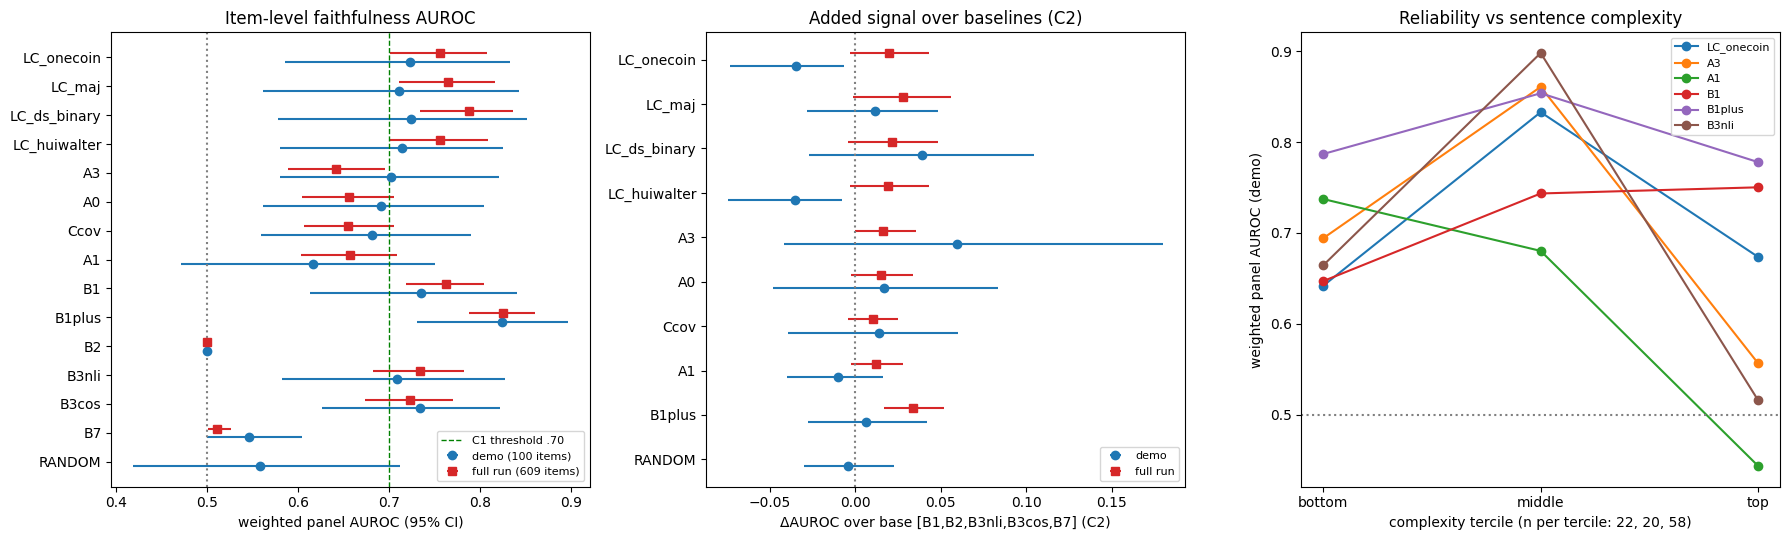

In [17]:
FULL = data["metadata"]["full_run_confirmation_table"]
KEY = ["LC_onecoin", "LC_maj", "LC_ds_binary", "LC_huiwalter", "A3", "A0", "Ccov", "A1", "B1", "B1plus", "B2",
       "B3nli", "B3cos", "B7", "RANDOM"]
KEY = [m for m in KEY if m in table]
print(f"{'metric':12s} | {'demo AUROC_P [95% CI]':26s} | {'demo C2 delta [CI]':24s} | {'full AUROC_P [CI]':24s} | "
      f"{'full C2 delta':13s} | full CONFIRMED")
print("-" * 125)
for m in KEY:
    t, st, f = table[m], stack["per_metric"].get(m, {}), FULL.get(m, {})
    d_c2 = f"{st['delta']:+.3f} {_ci(st['ci'])}" if st else "(in base)"
    f_c2 = f"{f['C2_delta']:+.3f}" if f.get("C2_delta") is not None else ("(in base)" if f else "-")
    f_auc = f"{_f(f.get('AUROC_P'))} {_ci(f.get('CI_P'))}" if f else "-"
    print(f"{m:12s} | {_f(t['P']['auroc'])} {_ci(t['P']['ci']):19s} | {d_c2:24s} | {f_auc:24s} | {f_c2:13s} | "
          f"{f.get('CONFIRMED', '-')}")
print("\nFull-run circularity (b), LC_onecoin inside 545 solver-non-equivalent items:",
      _f(data["metadata"]["full_run_circularity_b"]["LC_onecoin"]["auroc"]),
      _ci(data["metadata"]["full_run_circularity_b"]["LC_onecoin"]["ci"]),
      "->", data["metadata"]["full_run_circularity_b"]["LC_onecoin"]["preregistered_reading"])
print("Demo circularity (b):", _f(cb.get("LC_onecoin", {}).get("auroc")), _ci(cb.get("LC_onecoin", {}).get("ci")),
      "->", cb.get("LC_onecoin", {}).get("preregistered_reading"))

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
# (1) AUROC_P demo vs full
ax = axes[0]
yy = np.arange(len(KEY))
dm = np.array([table[m]["P"]["auroc"] for m in KEY])
dlo = np.array([table[m]["P"]["ci"][0] if table[m]["P"]["ci"][0] is not None else np.nan for m in KEY])
dhi = np.array([table[m]["P"]["ci"][1] if table[m]["P"]["ci"][1] is not None else np.nan for m in KEY])
ax.errorbar(dm, yy + 0.15, xerr=[dm - dlo, dhi - dm], fmt="o", color="#1f77b4", label="demo (100 items)")
fm = np.array([FULL.get(m, {}).get("AUROC_P", np.nan) or np.nan for m in KEY], dtype=float)
flo = np.array([(FULL.get(m, {}).get("CI_P") or [np.nan, np.nan])[0] for m in KEY], dtype=float)
fhi = np.array([(FULL.get(m, {}).get("CI_P") or [np.nan, np.nan])[1] for m in KEY], dtype=float)
ax.errorbar(fm, yy - 0.15, xerr=[fm - flo, fhi - fm], fmt="s", color="#d62728", label="full run (609 items)")
ax.axvline(0.5, color="grey", ls=":")
ax.axvline(0.70, color="green", ls="--", lw=1, label="C1 threshold .70")
ax.set_yticks(yy, KEY)
ax.invert_yaxis()
ax.set_xlabel("weighted panel AUROC (95% CI)")
ax.set_title("Item-level faithfulness AUROC")
ax.legend(loc="lower right", fontsize=8)
# (2) C2 delta over frozen base
ax = axes[1]
C2M = [m for m in KEY if m in stack["per_metric"]]
yy2 = np.arange(len(C2M))
dd = np.array([stack["per_metric"][m]["delta"] for m in C2M])
lo = np.array([stack["per_metric"][m]["ci"][0] for m in C2M])
hi = np.array([stack["per_metric"][m]["ci"][1] for m in C2M])
ax.errorbar(dd, yy2 + 0.15, xerr=[dd - lo, hi - dd], fmt="o", color="#1f77b4", label="demo")
fd = np.array([FULL.get(m, {}).get("C2_delta", np.nan) or np.nan for m in C2M], dtype=float)
fl = np.array([(FULL.get(m, {}).get("C2_ci") or [np.nan, np.nan])[0] for m in C2M], dtype=float)
fh = np.array([(FULL.get(m, {}).get("C2_ci") or [np.nan, np.nan])[1] for m in C2M], dtype=float)
ax.errorbar(fd, yy2 - 0.15, xerr=[fd - fl, fh - fd], fmt="s", color="#d62728", label="full run")
ax.axvline(0, color="grey", ls=":")
ax.set_yticks(yy2, C2M)
ax.invert_yaxis()
ax.set_xlabel("ΔAUROC over base [B1,B2,B3nli,B3cos,B7] (C2)")
ax.set_title("Added signal over baselines (C2)")
ax.legend(loc="lower right", fontsize=8)
# (3) AUROC by complexity tercile (demo)
ax = axes[2]
terc = [k for k in cx["per_cell"] if k.startswith("P|tn=")]
for m in cx_metrics:
    ax.plot([k.split("=")[1] for k in terc], [cx["per_cell"][k][m]["auroc"] for k in terc], marker="o", label=m)
ax.axhline(0.5, color="grey", ls=":")
ax.set_xticks(range(len(terc)), ["bottom", "middle", "top"])
ax.set_xlabel("complexity tercile (n per tercile: " + ", ".join(str(cx["per_cell"][k]["n"]) for k in terc) + ")")
ax.set_ylabel("weighted panel AUROC (demo)")
ax.set_title("Reliability vs sentence complexity")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Reading the demo against the full run

- **Point AUROCs match the full run's ordering.**
  - The frontier judge B1plus is on top (≈ .82 in both).
  - LC_*, B1 and the round-trip metrics come next (≈ .70–.79).
  - The structural metrics B2/B7 sit at ≈ .50, meaning parse validity and structural consistency do not track faithfulness.
- **C2 (added signal) fails for every candidate here as in the full run.** On 100 items the CIs are about 3× wider, so C2 cannot be settled either way at this scale. The full run's only lower bound > 0 is the *baseline* B1plus (+.034 [.017,.052]).
- **Circularity (b) and the placebo stacking feature are the least stable numbers at n = 100.**
  - In the full run (545 solver-non-equivalent items), LC_onecoin scores .722 [.669,.770], which reads *"not a checker artefact"*. On the ~90 such demo items its CI straddles 0.5.
  - The random placebo's Δ can move a few points on 100 items; on 609 items it is ≈ 0.

  To reproduce the full numbers, run `uv run method.py --stage analysis` in the experiment workspace, which uses all 609 panel items plus the 6,300-row solver labels.
- **Complexity cells** below 40 items are flagged `insufficient_n`, as in the original. The full run found no complexity crossover: in the top tercile, B1 scores .779 against LC .719.